# CYBER 207 — PII Detection: Evaluation & Error-Analysis Dashboard

**Specialized PII Detection Comparison** · binary screening of prompts as **safe (0)** vs **privacy-sensitive / PII (1)**
before they are sent to an external LLM (a Data-Loss-Prevention / DLP use case).

This notebook is a **self-contained evaluation dashboard** that consolidates every model built in the project and turns
their results into a single visual, comparable, DLP-oriented picture. It answers four questions the rubric cares about:

1. **How good is each model?** — Accuracy, Precision, Recall, F1 (per class + macro), plus DLP-specific rates (FNR, FPR, MCC).
2. **Where does each model fail?** — a confusion matrix per model and an explicit **False-Negative vs False-Positive** breakdown.
3. **What does each model *typically miss*?** — data-driven error patterns (languages, PII categories, text shape, masking artifacts).
4. **How do we fix it?** — concrete **feature-engineering recommendations**, each tied to a specific observed error, that should
   shrink the error margins.

> **Why the DLP framing matters.** In a screening layer a **false negative = leaked PII** (high risk), while a **false positive
> = user friction** (low risk). So we do not rank models by accuracy alone — we weight recall on the PII class and report the
> false-negative rate front-and-centre.

---
### Data-availability note (read me first)
The raw split parquet/CSV files are **git-ignored** and are *not* required to run this dashboard. Every model's confusion
matrix is embedded from its source notebook run (with provenance), so the dashboard is fully reproducible on its own. The
**one** model we recompute *live from row-level predictions* is the **Phi-4 LLM baseline** (`results/llm_baseline_results.csv`,
3,000 predictions), which also drives the deep, example-level error analysis. A drop-in loader (Section 6) lets you run the
*same* deep analysis on any other model the moment you export its predictions to a small CSV.

## 0 · Setup

In [1]:
import json, re, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# ---- consistent look & per-family colour map ------------------------------
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})
FAMILY_COLOR = {
    "Classical ML": "#4C78A8",
    "Neural Net":   "#72B7B2",
    "Transformer":  "#54A24B",
    "LLM baseline": "#E45756",
}

# Where to find the repo (this notebook lives in the project root when shipped).
# Falls back gracefully if the CSV is absent.
REPO = Path.cwd()
LLM_CSV_CANDIDATES = [
    REPO / "results" / "llm_baseline_results.csv",
    REPO.parent / "results" / "llm_baseline_results.csv",
    Path("results/llm_baseline_results.csv"),
]
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
print("Setup complete. Figures ->", FIG_DIR.resolve())

Setup complete. Figures -> /home/alph9w0lf/Nextcloud/00. Berkeley/06. CYBER 207/__Assignments/Final Project/cyber207_specialized_PII_detection_comparison/notebooks/figures


## 1 · Consolidated results (single source of truth)

Every model is stored as a raw confusion matrix `(TN, FP, FN, TP)` with **PII = the positive class**, plus the eval set it
was measured on and a pointer back to the exact source cell. Storing raw counts (not pre-computed metrics) means every metric
below is derived transparently and can be audited.

| Model | Family | Features | Eval set | Source |
|---|---|---|---|---|
| Logistic Regression | Classical ML | combined (50,018) | test | `03_classical_models.ipynb` (tuned t=0.416) |
| Naive Bayes | Classical ML | combined (50,018) | test | `03_classical_models.ipynb` (tuned t=0.332) |
| Linear SVM | Classical ML | combined (50,018) | test | `03_classical_models.ipynb` (tuned t=−0.177) |
| MLP (Neural Net) | Neural Net | combined (50,018) | test | `04_neural_net.ipynb` (deployed t=0.02; 0.5 kept as reference row) |
| DistilBERT | Transformer | sub-word tokens | test (val kept as reference) | `05_distilbert.ipynb` |
| Phi-4 LLM | LLM baseline | prompted (zero-shot) | test-subset (3,000) | `results/llm_baseline_results.csv`, recomputed live below |


In [2]:
# (TN, FP, FN, TP), PII = positive. Numbers transcribed from each model's own notebook output.
# SYNCED 2026-07-21 to notebooks 03-05: canonical rows are the HELD-OUT TEST SET, every trained
# model uses the SHARED combined feature space from 02_feature_engineering (TF-IDF 50k + 10
# text-shape + 8 pattern flags = 50,018 cols), and each model is evaluated at ITS OWN tuned
# operating point -- the comparison is "how well does each do the PII-detection job", not a
# shared arbitrary threshold. Classical CMs are reconstructed exactly from 03's 4-decimal test
# metrics (SVM counts now confirmed by results/classical_confusion_matrices.csv).
# Phi-4 fallback counts are the POST-placeholder-fix run
# (docs/brandon_error_analysis.md §2.2); the cell below recomputes them live from the CSV anyway.
MODEL_RESULTS = {
    "Logistic Regression": dict(family="Classical ML", features="combined (50,018)",
        eval_set="test", TN=7012, FP=3605, FN=1841, TP=20085,
        source="03_classical_models.ipynb · tuned LR, threshold 0.416", canonical=True),
    "Naive Bayes": dict(family="Classical ML", features="combined (50,018)",
        eval_set="test", TN=3658, FP=6959, FN=1650, TP=20276,
        source="03_classical_models.ipynb · tuned MultinomialNB, threshold 0.332", canonical=True),
    "Linear SVM": dict(family="Classical ML", features="combined (50,018)",
        eval_set="test", TN=7110, FP=3507, FN=1931, TP=19995,
        source="03_classical_models.ipynb · tuned LinearSVM C=0.25, threshold -0.177", canonical=True),
    "MLP (Neural Net)": dict(family="Neural Net", features="combined (50,018)",
        eval_set="test", TN=5898, FP=4719, FN=1350, TP=20576,
        source="04_neural_net.ipynb · deployed threshold 0.02 (recall-first)", canonical=True),
    "MLP @0.5 (reference)": dict(family="Neural Net", features="combined (50,018)",
        eval_set="test", TN=7993, FP=2624, FN=3005, TP=18921,
        source="04_neural_net.ipynb · fixed 0.5 comparison threshold", canonical=False),
    "DistilBERT": dict(family="Transformer", features="sub-word tokens",
        eval_set="test", TN=10223, FP=394, FN=447, TP=21479,
        source="05_distilbert.ipynb · held-out test confusion_matrix", canonical=True),
    "DistilBERT (val)": dict(family="Transformer", features="sub-word tokens",
        eval_set="validation", TN=10263, FP=353, FN=409, TP=21517,
        source="05_distilbert.ipynb · val confusion_matrix", canonical=False),
    "Phi-4 LLM": dict(family="LLM baseline", features="prompted (zero-shot)",
        eval_set="test-subset", TN=597, FP=382, FN=406, TP=1615,
        source="post-placeholder-fix run (fallback; recomputed live below)", canonical=True),
}
for m, d in MODEL_RESULTS.items():
    d["N"] = d["TN"] + d["FP"] + d["FN"] + d["TP"]
print(f"{len(MODEL_RESULTS)} model rows loaded.")



# ---- single-source override: the model notebooks now export their confusion matrices to
# results/*.csv (03: classical, 04: mlp, 05: distilbert + the Phi-4-subset script). When those
# files exist they replace the transcribed rows above, so 06 needs no manual syncing.
def _results(pth):
    for base in (REPO / "results", REPO.parent / "results"):
        if (base / pth).exists(): return base / pth
    return None

_f = _results("classical_confusion_matrices.csv")
if _f is not None:
    for _, r in pd.read_csv(_f).iterrows():
        if r["model"] in MODEL_RESULTS:
            MODEL_RESULTS[r["model"]].update(TN=int(r["tn"]), FP=int(r["fp"]), FN=int(r["fn"]), TP=int(r["tp"]),
                                             source=f"{_f.name} (test, tuned threshold)")
    print("classical rows <- classical_confusion_matrices.csv")

_f = _results("mlp_confusion_matrices.csv")
if _f is not None:
    for _, r in pd.read_csv(_f).iterrows():
        if bool(r["canonical"]):
            MODEL_RESULTS["MLP (Neural Net)"].update(TN=int(r["tn"]), FP=int(r["fp"]), FN=int(r["fn"]), TP=int(r["tp"]),
                                                     source=f"{_f.name} (test, deployed 0.02)")
        elif r["eval_set"] == "test" and r["operating_point"] == "fixed-0.5":
            MODEL_RESULTS["MLP @0.5 (reference)"].update(TN=int(r["tn"]), FP=int(r["fp"]), FN=int(r["fn"]), TP=int(r["tp"]),
                                                         source=f"{_f.name} (test, fixed 0.5)")
    print("MLP rows <- mlp_confusion_matrices.csv")

_f = _results("distilbert_confusion_matrices.csv")
if _f is not None:
    for _, r in pd.read_csv(_f).iterrows():
        key = "DistilBERT" if bool(r["canonical"]) else "DistilBERT (val)"
        MODEL_RESULTS[key].update(TN=int(r["tn"]), FP=int(r["fp"]), FN=int(r["fn"]), TP=int(r["tp"]),
                                  source=f"{_f.name} ({r['eval_set']})")
    print("DistilBERT rows <- distilbert_confusion_matrices.csv")

_f = _results("distilbert_on_phi4_subset.csv")
if _f is not None:
    r = pd.read_csv(_f).iloc[0]
    MODEL_RESULTS["DistilBERT (Phi-4 subset)"] = dict(
        family="Transformer", features="sub-word tokens", eval_set="test-subset",
        TN=int(r["TN"]), FP=int(r["FP"]), FN=int(r["FN"]), TP=int(r["TP"]),
        source=_f.name, canonical=False)
    print("subset comparability row <- distilbert_on_phi4_subset.csv")

for m, d in MODEL_RESULTS.items():
    d["N"] = d["TN"] + d["FP"] + d["FN"] + d["TP"]
print(f"{len(MODEL_RESULTS)} model rows ready.")

8 model rows loaded.
classical rows <- classical_confusion_matrices.csv
MLP rows <- mlp_confusion_matrices.csv
DistilBERT rows <- distilbert_confusion_matrices.csv
subset comparability row <- distilbert_on_phi4_subset.csv
9 model rows ready.


### 1.1 · Recompute the Phi-4 LLM baseline *live* from row-level predictions

If `llm_baseline_results.csv` is present we overwrite the embedded LLM counts with freshly computed ones and keep the full
prediction frame `llm_df` for the deep error analysis in Section 5. `document_label` is the LLM's binary verdict
(1 = PII found, 0 = none, −1 = API failure); `true_label` is the AI4Privacy ground truth.

In [3]:
llm_df = None
llm_path = next((p for p in LLM_CSV_CANDIDATES if p.exists()), None)
if llm_path is not None:
    llm_df = pd.read_csv(llm_path)
    n_failed = int((llm_df["document_label"] == -1).sum())
    if n_failed:
        print(f"Note: {n_failed} failed API calls treated as 'no PII detected' (conservative).")
    llm_df["pred_label"] = llm_df["document_label"].clip(lower=0).astype(int)  # -1 -> 0
    yt, yp = llm_df["true_label"].astype(int), llm_df["pred_label"]
    TN = int(((yt == 0) & (yp == 0)).sum()); FP = int(((yt == 0) & (yp == 1)).sum())
    FN = int(((yt == 1) & (yp == 0)).sum()); TP = int(((yt == 1) & (yp == 1)).sum())
    MODEL_RESULTS["Phi-4 LLM"].update(TN=TN, FP=FP, FN=FN, TP=TP, N=TN+FP+FN+TP,
                                      source=f"{llm_path.name} (recomputed live, {TN+FP+FN+TP} rows)")
    print(f"Live Phi-4 counts  ->  TN={TN}  FP={FP}  FN={FN}  TP={TP}  (N={TN+FP+FN+TP})")
else:
    print("llm_baseline_results.csv not found — using embedded Phi-4 counts (dashboard still fully renders).")

Live Phi-4 counts  ->  TN=597  FP=382  FN=406  TP=1615  (N=3000)


## 2 · Metrics engine

From a single confusion matrix we derive everything the rubric asks for and the DLP-specific rates that make the comparison
meaningful under class imbalance (67% PII / 33% safe):

* **Accuracy** — overall correctness (misleading alone under imbalance, shown for completeness).
* **Precision / Recall / F1 (PII)** — quality on the class we care about protecting against.
* **Precision / Recall / F1 (Safe)** and **Macro-F1** — balanced view across both classes.
* **FNR** = FN / (FN+TP) — the **leak rate**: fraction of real PII that slips through (⬇ better, the DLP headline).
* **FPR** = FP / (FP+TN) — the **false-alarm rate**: fraction of safe prompts needlessly blocked (⬇ better).
* **MCC** — Matthews correlation, a single balanced score robust to imbalance (−1..1, ⬆ better).
* **Balanced accuracy** — mean of the two class recalls.

In [4]:
def metrics_from_cm(TN, FP, FN, TP):
    N = TN + FP + FN + TP
    def safe(n, d): return n / d if d else 0.0
    pP, pR = safe(TP, TP + FP), safe(TP, TP + FN)
    sP, sR = safe(TN, TN + FN), safe(TN, TN + FP)
    pF1 = safe(2 * pP * pR, pP + pR); sF1 = safe(2 * sP * sR, sP + sR)
    denom = np.sqrt(float((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)))
    mcc = safe(TP*TN - FP*FN, denom)
    return {
        "Accuracy":       safe(TP + TN, N),
        "Precision (PII)": pP, "Recall (PII)": pR, "F1 (PII)": pF1,
        "Precision (Safe)": sP, "Recall (Safe)": sR, "F1 (Safe)": sF1,
        "Macro-F1":       (pF1 + sF1) / 2,
        "Balanced Acc":   (pR + sR) / 2,
        "MCC":            mcc,
        "FNR (leak rate)": safe(FN, FN + TP),
        "FPR (false alarm)": safe(FP, FP + TN),
        "N": N, "TN": TN, "FP": FP, "FN": FN, "TP": TP,
    }

rows = []
for name, d in MODEL_RESULTS.items():
    m = metrics_from_cm(d["TN"], d["FP"], d["FN"], d["TP"])
    m.update(Model=name, Family=d["family"], Features=d["features"],
             **{"Eval set": d["eval_set"]}, canonical=d["canonical"])
    rows.append(m)

metrics_df = pd.DataFrame(rows).set_index("Model")
# canonical view = one row per distinct model for the headline charts
canon = metrics_df[metrics_df["canonical"]].copy()
ORDER = ["Naive Bayes", "Linear SVM", "Logistic Regression", "MLP (Neural Net)", "Phi-4 LLM", "DistilBERT"]
canon = canon.loc[[m for m in ORDER if m in canon.index] +
                  [m for m in canon.index if m not in ORDER]]   # file-driven extras keep their place
# derived-metrics table is a results artifact, not a notebook-folder file
_out = (REPO / "results" if (REPO / "results").exists() else REPO.parent / "results") / "model_metrics_full.csv"
metrics_df.to_csv(_out)
print(f"Saved {_out}")

Saved /home/alph9w0lf/Nextcloud/00. Berkeley/06. CYBER 207/__Assignments/Final Project/cyber207_specialized_PII_detection_comparison/results/model_metrics_full.csv


In [5]:
# Headline leaderboard, ranked by the DLP-relevant Macro-F1
show_cols = ["Family", "Eval set", "Accuracy", "Precision (PII)", "Recall (PII)",
             "F1 (PII)", "Macro-F1", "MCC", "FNR (leak rate)", "FPR (false alarm)"]
leaderboard = (metrics_df[show_cols + ["canonical"]]
               .sort_values("Macro-F1", ascending=False))
def _style(df):
    num = df.select_dtypes("number").columns
    return (df.style.format({c: "{:.3f}" for c in num})
              .background_gradient(cmap="RdYlGn", subset=["Macro-F1", "F1 (PII)", "MCC"])
              .background_gradient(cmap="RdYlGn_r", subset=["FNR (leak rate)", "FPR (false alarm)"])
              .set_caption("Model leaderboard — sorted by Macro-F1. Green = better. "
                           "FNR/FPR use reversed colours (lower = better)."))
_style(leaderboard.drop(columns="canonical"))

,Family,Eval set,Accuracy,Precision (PII),Recall (PII),F1 (PII),Macro-F1,MCC,FNR (leak rate),FPR (false alarm)
Model,,,,,,,,,,
DistilBERT (val),Transformer,validation,0.977,0.984,0.981,0.983,0.973,0.947,0.019,0.033
DistilBERT,Transformer,test,0.974,0.982,0.980,0.981,0.971,0.941,0.020,0.037
DistilBERT (Phi-4 subset),Transformer,test-subset,0.972,0.979,0.980,0.979,0.968,0.936,0.020,0.044
MLP @0.5 (reference),Neural Net,test,0.826,0.873,0.869,0.871,0.803,0.606,0.131,0.262
Linear SVM,Classical ML,test,0.833,0.851,0.912,0.880,0.802,0.609,0.088,0.330
Logistic Regression,Classical ML,test,0.833,0.848,0.916,0.881,0.800,0.607,0.084,0.340
MLP (Neural Net),Neural Net,test,0.816,0.815,0.940,0.873,0.769,0.562,0.060,0.440
Phi-4 LLM,LLM baseline,test-subset,0.737,0.809,0.799,0.804,0.703,0.406,0.201,0.390
Naive Bayes,Classical ML,test,0.735,0.744,0.925,0.825,0.642,0.342,0.075,0.655


## 3 · The dashboard

Six visual panels. Colour encodes model **family** (blue = classical ML, teal = neural net, green = transformer,
red = LLM). Read them together: panel A/B rank the models, C/D show *how* they fail, E/F reframe everything for DLP.

### Panel A · Core metrics side-by-side  (Accuracy · Precision · Recall · F1)

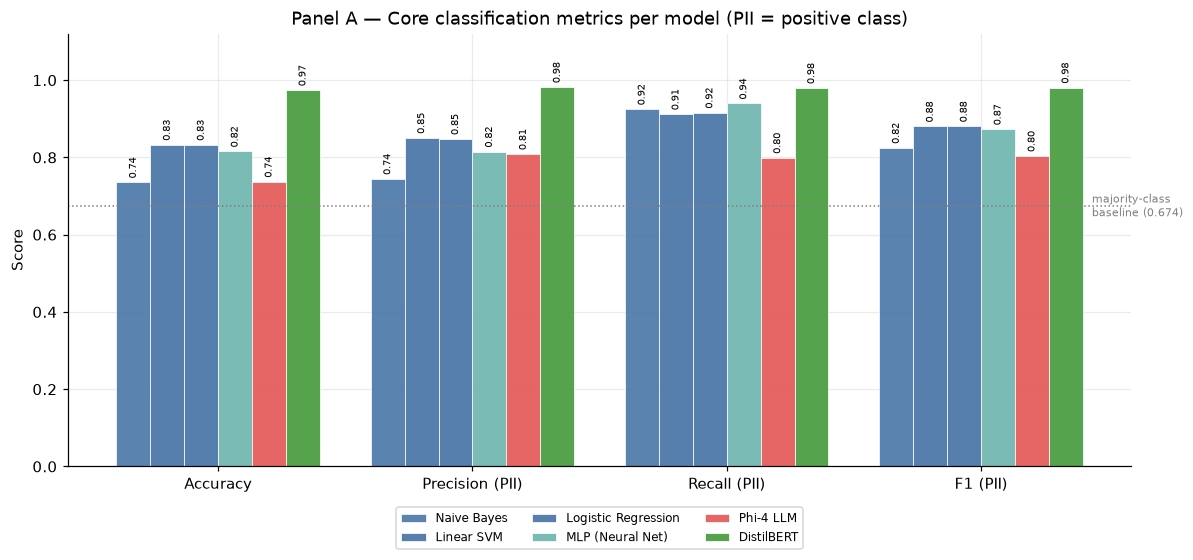

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.2))
mets = ["Accuracy", "Precision (PII)", "Recall (PII)", "F1 (PII)"]
models = list(canon.index)
x = np.arange(len(mets)); w = 0.8 / len(models)
for i, mdl in enumerate(models):
    vals = [canon.loc[mdl, k] for k in mets]
    ax.bar(x + i*w - 0.4 + w/2, vals, w, label=mdl,
           color=FAMILY_COLOR[canon.loc[mdl, "Family"]],
           edgecolor="white", linewidth=0.5,
           alpha=0.55 + 0.45*(canon.loc[mdl, "F1 (PII)"]))
    for xi, v in zip(x + i*w - 0.4 + w/2, vals):
        ax.text(xi, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=6.5, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(mets); ax.set_ylim(0, 1.12)
ax.set_ylabel("Score"); ax.set_title("Panel A — Core classification metrics per model (PII = positive class)")
ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.axhline(0.6737, ls=":", c="grey", lw=1)
ax.text(3.42, 0.6737, " majority-class\n baseline (0.674)", va="center", fontsize=7, c="grey")
plt.tight_layout(); plt.savefig(FIG_DIR / "panelA_core_metrics.png", bbox_inches="tight"); plt.show()

### Panel B · The DLP view — leak rate (FNR) vs false-alarm rate (FPR)

The bottom-left corner is ideal (few leaks, few false alarms). This is the single most decision-relevant chart for a
screening layer: it separates the *cost* of each model's mistakes.

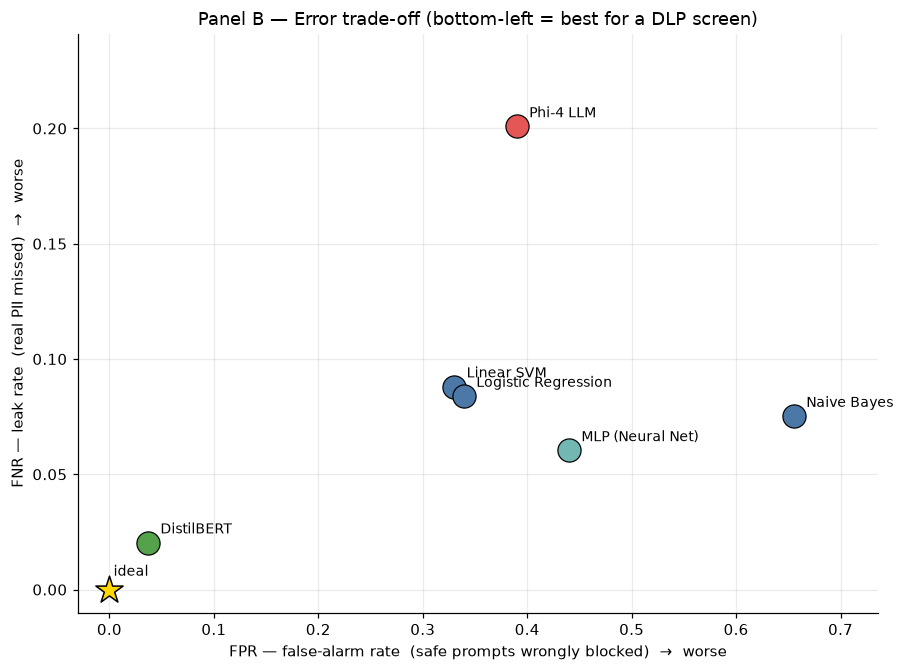

In [7]:
fig, ax = plt.subplots(figsize=(8.4, 6.2))
for mdl in canon.index:
    xr, yr = canon.loc[mdl, "FPR (false alarm)"], canon.loc[mdl, "FNR (leak rate)"]
    ax.scatter(xr, yr, s=230, color=FAMILY_COLOR[canon.loc[mdl, "Family"]],
               edgecolor="black", linewidth=0.8, zorder=3)
    ax.annotate(mdl, (xr, yr), xytext=(8, 6), textcoords="offset points", fontsize=9)
ax.set_xlabel("FPR — false-alarm rate  (safe prompts wrongly blocked)  →  worse")
ax.set_ylabel("FNR — leak rate  (real PII missed)  →  worse")
ax.set_title("Panel B — Error trade-off (bottom-left = best for a DLP screen)")
ax.set_xlim(-0.03, max(canon["FPR (false alarm)"]) + 0.08)
ax.set_ylim(-0.01, max(canon["FNR (leak rate)"]) + 0.04)
ax.scatter(0, 0, marker="*", s=350, color="gold", edgecolor="black", zorder=4)
ax.text(0.004, 0.006, "ideal", fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / "panelB_error_tradeoff.png", bbox_inches="tight"); plt.show()

### Panel C · Confusion matrix per model

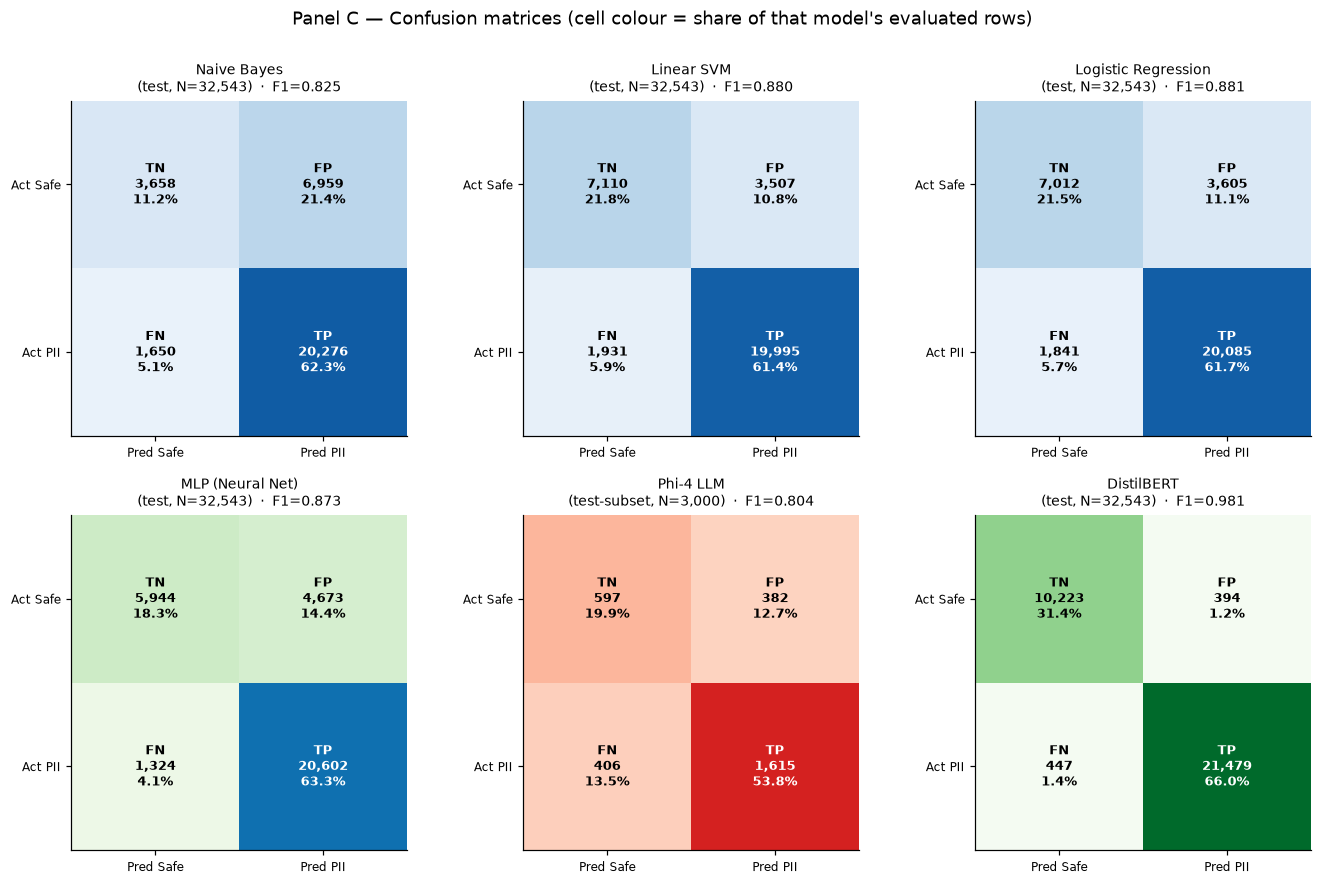

In [8]:
def plot_cm(ax, name, d, cmap="Blues"):
    cm = np.array([[d["TN"], d["FP"]], [d["FN"], d["TP"]]])
    tot = cm.sum()
    ax.imshow(cm / tot, cmap=cmap, vmin=0, vmax=0.75)
    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / tot
            ax.text(j, i, f"{labels[i][j]}\n{cm[i,j]:,}\n{pct:.1%}",
                    ha="center", va="center", fontsize=8.5,
                    color="white" if pct > 0.4 else "black", fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred Safe", "Pred PII"], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Act Safe", "Act PII"], fontsize=8)
    m = metrics_from_cm(d["TN"], d["FP"], d["FN"], d["TP"])
    ax.set_title(f"{name}\n({d['eval_set']}, N={d['N']:,})  ·  F1={m['F1 (PII)']:.3f}", fontsize=9)
    ax.grid(False)

fam_cmap = {"Classical ML": "Blues", "Neural Net": "GnBu", "Transformer": "Greens", "LLM baseline": "Reds"}
fig, axes = plt.subplots(2, 3, figsize=(12.5, 8))
for ax, mdl in zip(axes.ravel(), canon.index):
    plot_cm(ax, mdl, MODEL_RESULTS[mdl], fam_cmap[canon.loc[mdl, "Family"]])
fig.suptitle("Panel C — Confusion matrices (cell colour = share of that model's evaluated rows)", y=1.0, fontsize=12)
plt.tight_layout(); plt.savefig(FIG_DIR / "panelC_confusion_matrices.png", bbox_inches="tight"); plt.show()

### Panel D · Error composition — *how* each model is wrong

Normalised to errors **per 1,000 evaluated prompts** so models measured on different-sized sets are comparable. Bars split
each model's mistakes into **missed PII (FN, dark = dangerous)** and **false alarms (FP, light = friction)**.

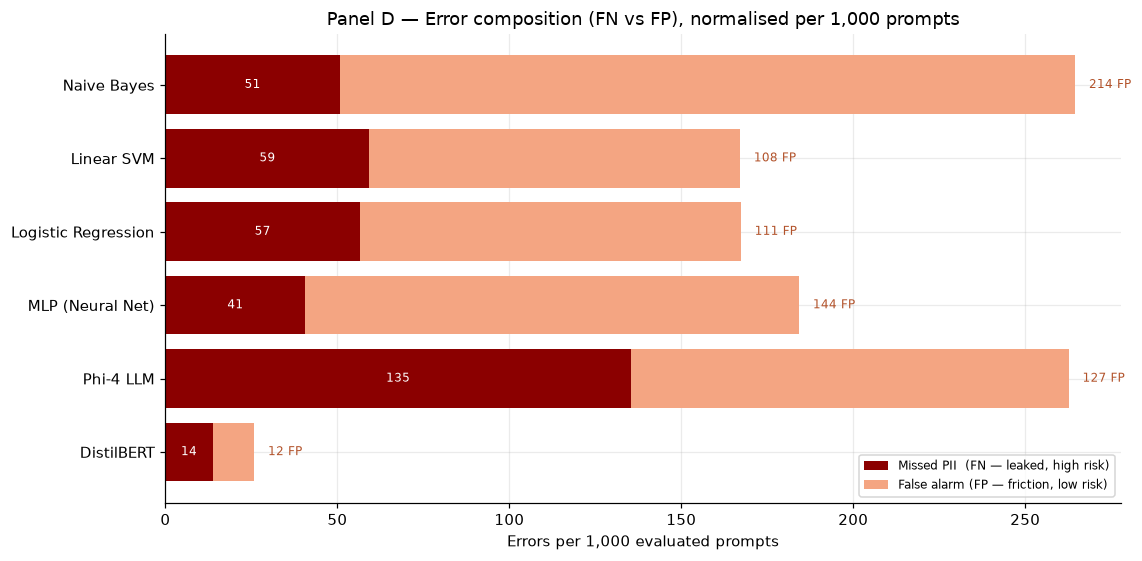

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
models = list(canon.index)
fn_k = [canon.loc[m, "FN"] / canon.loc[m, "N"] * 1000 for m in models]
fp_k = [canon.loc[m, "FP"] / canon.loc[m, "N"] * 1000 for m in models]
y = np.arange(len(models))
ax.barh(y, fn_k, color="#8B0000", label="Missed PII  (FN — leaked, high risk)")
ax.barh(y, fp_k, left=fn_k, color="#F4A582", label="False alarm (FP — friction, low risk)")
for i, m in enumerate(models):
    ax.text(fn_k[i]/2 if fn_k[i] > 12 else fn_k[i]+3, i, f"{fn_k[i]:.0f}",
            va="center", ha="center" if fn_k[i] > 12 else "left", fontsize=8,
            color="white" if fn_k[i] > 12 else "black")
    ax.text(fn_k[i] + fp_k[i] + 4, i, f"{fp_k[i]:.0f} FP", va="center", fontsize=8, color="#B2522A")
ax.set_yticks(y); ax.set_yticklabels(models)
ax.set_xlabel("Errors per 1,000 evaluated prompts")
ax.set_title("Panel D — Error composition (FN vs FP), normalised per 1,000 prompts")
ax.legend(loc="lower right", fontsize=8); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(FIG_DIR / "panelD_error_composition.png", bbox_inches="tight"); plt.show()

### Panel E · DLP cost-weighted ranking

A screening layer does not treat a leak and a false alarm equally. We score each model with an explicit cost ratio —
**a missed PII costs `C_FN` times as much as a false alarm** — and rank by total cost per 1,000 prompts. Slide `C_FN` to
see how the ranking shifts as you get stricter about leaks.

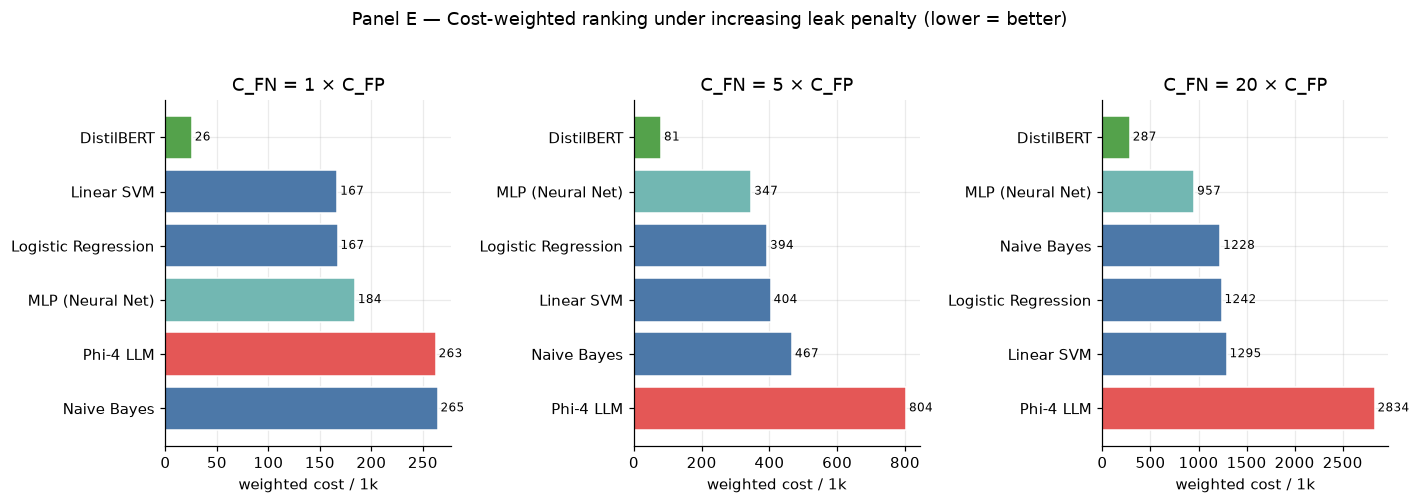

In [10]:
def cost_rank(c_fn=5, c_fp=1):
    out = []
    for m in canon.index:
        d = MODEL_RESULTS[m]
        cost = (c_fn * d["FN"] + c_fp * d["FP"]) / d["N"] * 1000
        out.append((m, cost))
    return pd.DataFrame(out, columns=["Model", "cost_per_1k"]).sort_values("cost_per_1k")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=False)
for ax, c in zip(axes, [1, 5, 20]):
    r = cost_rank(c_fn=c)
    colors = [FAMILY_COLOR[canon.loc[m, "Family"]] for m in r["Model"]]
    ax.barh(r["Model"], r["cost_per_1k"], color=colors, edgecolor="white")
    ax.invert_yaxis(); ax.set_title(f"C_FN = {c} × C_FP")
    ax.set_xlabel("weighted cost / 1k")
    for i, (m, v) in enumerate(zip(r["Model"], r["cost_per_1k"])):
        ax.text(v + max(r['cost_per_1k'])*0.01, i, f"{v:.0f}", va="center", fontsize=8)
fig.suptitle("Panel E — Cost-weighted ranking under increasing leak penalty (lower = better)", y=1.03, fontsize=12)
plt.tight_layout(); plt.savefig(FIG_DIR / "panelE_cost_ranking.png", bbox_inches="tight"); plt.show()

### Panel F · One-glance scorecard

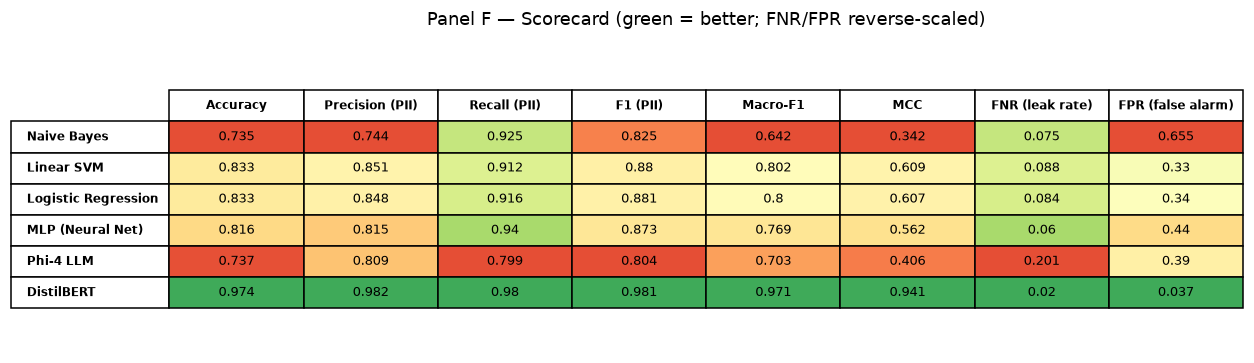

In [11]:
fig, ax = plt.subplots(figsize=(11.5, 3.4))
ax.axis("off")
cols = ["Accuracy", "Precision (PII)", "Recall (PII)", "F1 (PII)", "Macro-F1", "MCC", "FNR (leak rate)", "FPR (false alarm)"]
tbl = canon[cols].round(3)
# build colour grid as nested python lists (rows x cols); numpy would flatten RGBA tuples
ranges = {c: (tbl[c].min(), tbl[c].max()) for c in cols}
cell_colours = []
for mdl in tbl.index:
    row = []
    for c in cols:
        lo, hi = ranges[c]
        v = tbl.loc[mdl, c]
        t = 0.0 if hi == lo else (v - lo) / (hi - lo)
        if c in ("FNR (leak rate)", "FPR (false alarm)"): t = 1 - t
        row.append(plt.cm.RdYlGn(0.15 + 0.7 * t))
    cell_colours.append(row)
the = ax.table(cellText=tbl.round(3).values, rowLabels=tbl.index, colLabels=cols,
               cellColours=cell_colours, loc="center", cellLoc="center")
the.auto_set_font_size(False); the.set_fontsize(8.5); the.scale(1, 1.6)
for (r, c), cell in the.get_celld().items():
    if r == 0 or c == -1:
        cell.set_text_props(fontweight="bold", fontsize=8)
ax.set_title("Panel F — Scorecard (green = better; FNR/FPR reverse-scaled)", fontsize=12, pad=14)
plt.tight_layout(); plt.savefig(FIG_DIR / "panelF_scorecard.png", bbox_inches="tight"); plt.show()

#### What the dashboard says
* **DistilBERT wins decisively and cheaply** — test F1(PII) ≈ 0.981, MCC ≈ 0.94, leak rate ≈ 2.0%, at **2.4 ms/prompt**.
  Contextual sub-word embeddings solve what bag-of-words cannot, and (locally, on a 4090) they are not even slow.
* **The engineered combined features closed much of the gap** for the lightweight models: tuned LR/SVM now sit at
  test F1 ≈ 0.88 with recall ≈ 0.91–0.92 (up from ≈ 0.85 on raw TF-IDF), at ~1–2 ms/prompt end-to-end.
* **The MLP at its deployed 0.02 threshold is the best non-transformer leak-stopper**: recall 0.938, FN = 1,350
  (vs 3,005 at the fixed 0.5 reference row), paying with FPR ≈ 0.44 — the intended recall-first DLP trade, at a
  single-digit-millisecond end-to-end cost (exact figure in Panel G).
* **Naive Bayes remains the cautionary tale** — recall 0.925 only by flagging 66% of safe prompts.
* **The Phi-4 LLM baseline loses on both axes even after its targeted prompt fix** (macro-F1 0.65 → 0.70,
  FP 547 → 382 per `docs/brandon_error_analysis.md`): worse recall (0.80) than every tuned lightweight model *and*
  ~690 ms/prompt — ~290× slower than DistilBERT and two-plus orders of magnitude above every
  lightweight screen (exact ratios in Panel G, which reads the current benchmark file). This directly supports the
  project hypothesis: a lightweight engineered-feature screen is the practical pre-submission layer, with
  DistilBERT the quality ceiling when a GPU is available.


### Panel G · Prompt response time (ms per prompt)

How much does each screen cost per prompt? All rows are **end-to-end** (raw text → decision:
featurization/tokenization + model) and **single-prompt, sequential** — the shared protocol of
`src/latency_benchmark.py` (DistilBERT / Phi-4), `04_neural_net` STEP 9 (MLP), and
`03_classical_models`' `featurize_prompt` timing cell (100-prompt test sample, seed 42, warmup
excluded). The MLP forward-only row is kept as the one model-only reference point.


,Family,scope,Avg ms/prompt,Median ms/prompt,Min ms/prompt,Max ms/prompt
Model,,,,,,
MLP (Neural Net),Neural Net,model-only,0.440,0.330,0.240,2.640
Linear SVM,Classical ML,end-to-end,1.512,1.511,1.466,1.583
Logistic Regression,Classical ML,end-to-end,1.549,1.542,1.488,1.718
Naive Bayes,Classical ML,end-to-end,1.685,1.683,1.625,1.766
MLP (Neural Net),Neural Net,end-to-end,2.190,2.066,1.748,4.381
DistilBERT,Transformer,end-to-end,2.400,2.300,2.100,7.500
Phi-4 LLM,LLM baseline,end-to-end,688.800,736.000,174.300,1564.900


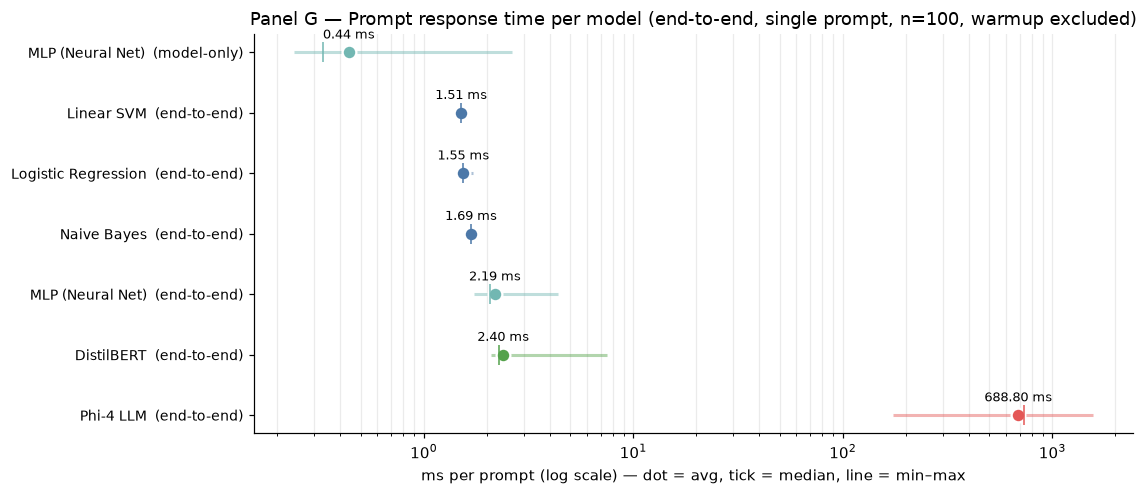

In [12]:
# Panel G -- prompt response time per model (avg / median / min / max, ms)
# Single source: results/latency_benchmark.csv (all models, end-to-end) plus the MLP
# forward-only row from results/mlp_latency_benchmark.csv.
FAMILY_OF = {"DistilBERT": "Transformer", "Phi-4": "LLM baseline", "Phi-4 LLM": "LLM baseline",
             "MLP (Neural Net)": "Neural Net", "Logistic Regression": "Classical ML",
             "Naive Bayes": "Classical ML", "Linear SVM": "Classical ML"}
def _results(pth):
    for base in (REPO / "results", REPO.parent / "results"):
        if (base / pth).exists(): return base / pth
    return None

lat_rows = []
_f = _results("latency_benchmark.csv")
if _f is not None:
    for _, r in pd.read_csv(_f).iterrows():
        name = {"Phi-4": "Phi-4 LLM"}.get(r["model"], r["model"])
        lat_rows.append(dict(Model=name, Family=FAMILY_OF.get(name, "?"), scope="end-to-end",
                             avg=r["mean_ms"], med=r["median_ms"], mn=r["min_ms"], mx=r["max_ms"]))
_f = _results("mlp_latency_benchmark.csv")
if _f is not None:
    _m = pd.read_csv(_f).set_index("stage")
    if not any(r["Model"] == "MLP (Neural Net)" and r["scope"] == "end-to-end" for r in lat_rows):
        r = _m.loc["end-to-end (features + MLP)"]
        lat_rows.append(dict(Model="MLP (Neural Net)", Family="Neural Net", scope="end-to-end",
                             avg=r["avg_ms_per_prompt"], med=r["median_ms_per_prompt"],
                             mn=r["min_ms_per_prompt"], mx=r["max_ms_per_prompt"]))
    r = _m.loc["MLP forward only"]
    lat_rows.append(dict(Model="MLP (Neural Net)", Family="Neural Net", scope="model-only",
                         avg=r["avg_ms_per_prompt"], med=r["median_ms_per_prompt"],
                         mn=r["min_ms_per_prompt"], mx=r["max_ms_per_prompt"]))

lat_df = (pd.DataFrame(lat_rows).drop_duplicates(subset=["Model", "scope"])
            .set_index("Model")
            .rename(columns={"avg": "Avg ms/prompt", "med": "Median ms/prompt",
                             "mn": "Min ms/prompt", "mx": "Max ms/prompt"})
            .sort_values("Avg ms/prompt"))
display(lat_df.round(3))

# dot + min-max range on a log axis (bars are unreadable across 4 orders of magnitude)
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ypos = np.arange(len(lat_df))[::-1]
for y, (mdl, r) in zip(ypos, lat_df.iterrows()):
    c = FAMILY_COLOR.get(r["Family"], "#888888")
    ax.hlines(y, r["Min ms/prompt"], r["Max ms/prompt"], color=c, lw=2, alpha=0.45)
    ax.plot(r["Avg ms/prompt"], y, "o", ms=9, color=c, zorder=3, markeredgecolor="white", markeredgewidth=1.5)
    ax.plot(r["Median ms/prompt"], y, "|", ms=13, color=c, zorder=3)
    ax.annotate(f'{r["Avg ms/prompt"]:.2f} ms', (r["Avg ms/prompt"], y),
                textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8.5)
ax.set_yticks(ypos)
ax.set_yticklabels([f'{m}  ({r["scope"]})' for m, r in lat_df.iterrows()], fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("ms per prompt (log scale) — dot = avg, tick = median, line = min–max")
ax.set_title("Panel G — Prompt response time per model (end-to-end, single prompt, n=100, warmup excluded)")
ax.grid(axis="x", which="both", alpha=0.25); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.savefig(FIG_DIR / "panelG_latency.png", bbox_inches="tight"); plt.show()


**Reading Panel G** — with every model timed **end-to-end**, the spread is two-plus orders of magnitude:
the lightweight screeners (classical, MLP, DistilBERT) all land in a **~1.5–2.5 ms band**, while the Phi-4
baseline needs ~689 ms with huge variance (174–1,565 ms). Featurization dominates the lightweight pipelines,
which is why they cluster — and why DistilBERT, despite being a transformer, sits inside that band while
being the most accurate model. Note on exact values: the classical and MLP timings are re-measured every
time notebooks 03/04 are re-run and shift with machine load (successive runs have varied by ~2×), so **the
chart above and `results/latency_benchmark.csv` are the authority for current figures**; the DistilBERT
(2.4 ms) and Phi-4 (688.8 ms) rows come from the pinned `src/latency_benchmark.py` run and are stable.
The LLM baseline is hundreds of times slower than every screening option with the weakest tuned recall:
the cost-of-inference argument at the heart of the project hypothesis.


## 4 · A reusable error-analysis engine

Section 5 needs to slice *every* mistake by language, text-shape, and PII category. Because only the LLM baseline ships
row-level predictions, we build the analysis as a **reusable function**: hand it any frame with `text`, `true_label`,
`pred_label` and it returns the same taxonomy for any model (Section 6 shows how to export those three columns from each
modelling notebook in one line).

In [13]:
PLACEHOLDER_RE = re.compile(r"\[[A-Z][A-Z0-9_]*\]")   # AI4Privacy masking artifacts e.g. [IPV4_1], [NAME_1]
HTML_RE        = re.compile(r"<[^>]+>|&(?:amp|lt|gt|quot|nbsp);")
LANG_MARKERS = {
    "German (de)":  r"\b(der|die|das|und|ich|nicht|mein|Ihre|für|über|bitte)\b",
    "French (fr)":  r"\b(le|la|les|je|vous|votre|pour|avec|est|une|bonjour)\b",
    "Spanish (es)": r"\b(el|los|mi|para|con|una|está|su|por|hola|gracias)\b",
    "Italian (it)": r"\b(il|di|che|per|con|una|sono|del|prego|buongiorno)\b",
    "Dutch (nl)":   r"\b(het|een|ik|voor|met|niet|mijn|alstublieft)\b",
    "English (en)": r"\b(the|and|is|to|my|for|with|you|your|please|hello)\b",
}
def guess_lang(t):
    t = str(t)
    for lang, pat in LANG_MARKERS.items():
        if re.search(pat, t, flags=re.IGNORECASE):
            return lang
    return "other/unknown"

def analyze_predictions(df, text="text", true="true_label", pred="pred_label", name="model"):
    d = df[[text, true, pred]].copy()
    d.columns = ["text", "true", "pred"]
    d["text"] = d["text"].astype(str)
    d["is_fn"] = (d.true == 1) & (d.pred == 0)   # missed PII  (dangerous)
    d["is_fp"] = (d.true == 0) & (d.pred == 1)   # false alarm
    d["len"] = d.text.str.len()
    d["has_placeholder"] = d.text.str.contains(PLACEHOLDER_RE)
    d["has_html"] = d.text.str.contains(HTML_RE)
    d["lang"] = d.text.map(guess_lang)
    fn, fp = d[d.is_fn], d[d.is_fp]
    pii, safe = d[d.true == 1], d[d.true == 0]
    def rate(sub, col): return float(sub[col].mean()) if len(sub) else float("nan")
    summary = {
        "name": name, "n": len(d), "FN": int(d.is_fn.sum()), "FP": int(d.is_fp.sum()),
        "median_len_PII": float(pii.len.median()), "median_len_FN": float(fn.len.median()) if len(fn) else float("nan"),
        "median_len_safe": float(safe.len.median()), "median_len_FP": float(fp.len.median()) if len(fp) else float("nan"),
        "placeholder_rate_FP": rate(fp, "has_placeholder"), "placeholder_rate_safe": rate(safe, "has_placeholder"),
        "html_rate_FN": rate(fn, "has_html"), "html_rate_PII": rate(pii, "has_html"),
    }
    # language breakdown of leaks (FN rate among true PII per language)
    lang_tbl = (pii.groupby("lang")
                   .agg(true_PII=("is_fn", "size"), missed=("is_fn", "sum"))
                   .assign(leak_rate=lambda t: (t.missed / t.true_PII).round(3))
                   .sort_values("true_PII", ascending=False))
    return d, summary, lang_tbl, fn, fp
print("analyze_predictions() ready.")

analyze_predictions() ready.


## 5 · Deep error analysis — Phi-4 LLM baseline (data-driven)

This is the one model with row-level predictions, so we can see *exactly* what it fails on. The findings here also stand in
as the clearest evidence for **where pattern/keyword approaches break**, because the LLM and the TF-IDF models make
structurally similar mistakes (over-flagging string-shaped tokens, missing soft/contextual PII).

In [14]:
if llm_df is not None:
    d_llm, s_llm, lang_llm, fn_llm, fp_llm = analyze_predictions(llm_df, name="Phi-4 LLM")
    print(f"Phi-4 baseline · N={s_llm['n']}  |  Missed PII (FN)={s_llm['FN']}  |  False alarms (FP)={s_llm['FP']}")
    print(f"Dominant failure mode: {'FALSE POSITIVES (over-flagging)' if s_llm['FP']>s_llm['FN'] else 'FALSE NEGATIVES (missing PII)'}")
    print(f"\nText length (chars):  all-PII median={s_llm['median_len_PII']:.0f}  vs  missed-PII(FN) median={s_llm['median_len_FN']:.0f}")
    print(f"                      all-safe median={s_llm['median_len_safe']:.0f}  vs  false-alarm(FP) median={s_llm['median_len_FP']:.0f}")
    print(f"Masking-artifact [PLACEHOLDER] present:  in FPs={s_llm['placeholder_rate_FP']:.1%}  vs safe overall={s_llm['placeholder_rate_safe']:.1%}")
else:
    print("LLM CSV not available — skipping data-driven deep dive (see embedded findings in markdown).")

Phi-4 baseline · N=3000  |  Missed PII (FN)=406  |  False alarms (FP)=382
Dominant failure mode: FALSE NEGATIVES (missing PII)

Text length (chars):  all-PII median=146  vs  missed-PII(FN) median=123
                      all-safe median=123  vs  false-alarm(FP) median=136
Masking-artifact [PLACEHOLDER] present:  in FPs=5.8%  vs safe overall=11.3%


### 5.1 · Leak rate by language  (heuristic language guess)

,true_PII,missed,leak_rate
lang,,,
French (fr),622,119,0.191
English (en),365,86,0.236
German (de),327,76,0.232
other/unknown,276,59,0.214
Italian (it),184,27,0.147
Spanish (es),154,25,0.162
Dutch (nl),93,14,0.151


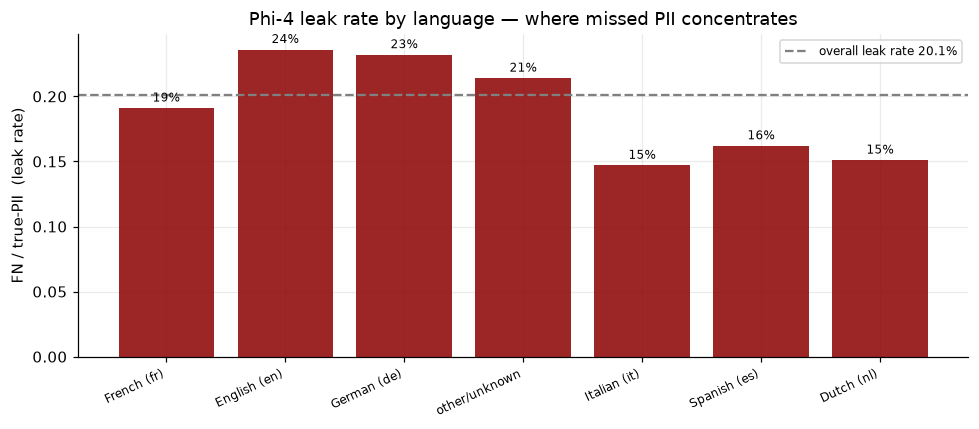

In [15]:
if llm_df is not None:
    display(lang_llm)
    fig, ax = plt.subplots(figsize=(9, 4))
    lt = lang_llm[lang_llm.true_PII >= 20]
    ax.bar(range(len(lt)), lt.leak_rate, color="#8B0000", alpha=0.85)
    ax.set_xticks(range(len(lt))); ax.set_xticklabels(lt.index, rotation=25, ha="right", fontsize=8)
    ax.axhline(s_llm["FN"]/ (llm_df.true_label==1).sum(), ls="--", c="grey",
               label=f"overall leak rate {s_llm['FN']/(llm_df.true_label==1).sum():.1%}")
    ax.set_ylabel("FN / true-PII  (leak rate)")
    ax.set_title("Phi-4 leak rate by language — where missed PII concentrates")
    for i, v in enumerate(lt.leak_rate): ax.text(i, v+0.005, f"{v:.0%}", ha="center", fontsize=8)
    ax.legend(fontsize=8); plt.tight_layout()
    plt.savefig(FIG_DIR / "llm_leak_by_language.png", bbox_inches="tight"); plt.show()

### 5.2 · What the LLM flags on **false positives**, and the labels it *invents*

Two distinct failure sources hide inside the false-alarm pile:
1. **Taxonomy-boundary disagreement** — the LLM flags string-shaped tokens (URLs, IP-like strings, long numbers, crypto
   addresses) that the AI4Privacy ground truth does *not* count as protected PII in that context.
2. **Instruction-following drift** — despite a constrained 18-label prompt, the model emits **off-taxonomy labels**
   (`password`, `pin`, `mac_address`, `vin`, `imei`, …). Any emitted entity collapses the document to "PII", so these
   hallucinated categories directly manufacture false positives.

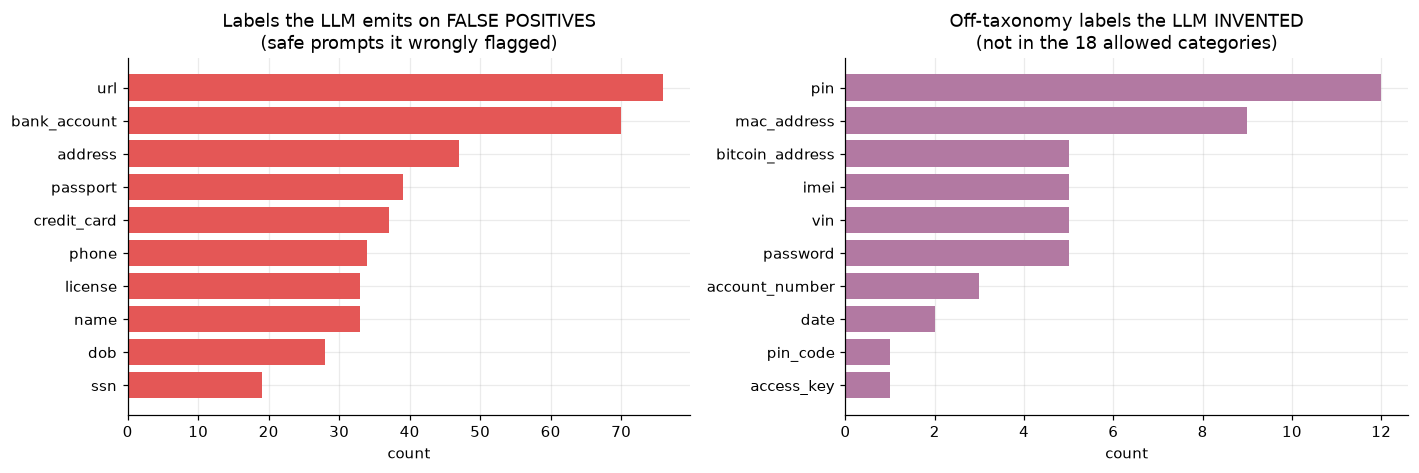

Off-taxonomy hallucinated entities (total): 54
False positives triggered on a masking [PLACEHOLDER] token: 22/382 = 5.8%


In [16]:
if llm_df is not None:
    def labels_of(js):
        try:
            arr = json.loads(js) if isinstance(js, str) else []
            return [str(e.get("label", "?")).lower() for e in arr if isinstance(e, dict)]
        except Exception:
            return []
    ALLOWED = set("name username email phone address dob ssn passport license credit_card "
                  "bank_account routing_number tax_id national_id student_id ip_address url mrn".split())
    fp_labels = Counter()
    for js in fp_llm.merge(llm_df, left_index=True, right_index=True)["entities_json"]:
        fp_labels.update(labels_of(js))
    off_tax = Counter()
    for js in llm_df["entities_json"]:
        for lab in labels_of(js):
            if lab not in ALLOWED: off_tax[lab] += 1

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
    top_fp = fp_labels.most_common(10)
    a1.barh([k for k, _ in top_fp][::-1], [v for _, v in top_fp][::-1], color="#E45756")
    a1.set_title("Labels the LLM emits on FALSE POSITIVES\n(safe prompts it wrongly flagged)")
    a1.set_xlabel("count")
    top_off = off_tax.most_common(10)
    a2.barh([k for k, _ in top_off][::-1], [v for _, v in top_off][::-1], color="#B279A2")
    a2.set_title("Off-taxonomy labels the LLM INVENTED\n(not in the 18 allowed categories)")
    a2.set_xlabel("count")
    plt.tight_layout(); plt.savefig(FIG_DIR / "llm_fp_labels.png", bbox_inches="tight"); plt.show()
    print("Off-taxonomy hallucinated entities (total):", sum(off_tax.values()))
    ph_fp = fp_llm.has_placeholder.sum()
    print(f"False positives triggered on a masking [PLACEHOLDER] token: {ph_fp}/{len(fp_llm)} = {ph_fp/len(fp_llm):.1%}")

### 5.3 · Concrete examples — the missed PII (FN) and the false alarms (FP)

In [17]:
if llm_df is not None:
    print("="*90, "\nFALSE NEGATIVES — real PII the LLM called 'safe' (the dangerous misses)\n" + "="*90)
    for t in fn_llm.text.head(8):
        print("  •", repr(t[:150]))
    print("\n" + "="*90, "\nFALSE POSITIVES — safe prompts the LLM flagged, with the entity it hallucinated\n" + "="*90)
    merged = fp_llm.merge(llm_df[["entities_json"]], left_index=True, right_index=True)
    for _, r in merged.head(8).iterrows():
        labs = [e.get("label") for e in (json.loads(r.entities_json) if isinstance(r.entities_json, str) else [])]
        print("  •", repr(r.text[:110]), "->", labs)

FALSE NEGATIVES — real PII the LLM called 'safe' (the dangerous misses)
  • 'Hallo Dr Ilkorkor, gibt es in der Schweiz bekannte Psycholinguistik-Konferenzen, die du empfehlen kannst? Würde gerne teilnehmen.'
  • '¡Buenas noticias! Me promovieron a Secretario administrativo en Sant Boi de Llobregat.'
  • 'Psychological assessment for residents in Newtonmore Laggan has been updated. Use 1g5I}TH to access your profile.'
  • 'Hallo Cami, bitte schau dir Vertragsnummer RECHN-201909-5950 an. Passwort: =qnK8'
  • '1. Fase critica iniziale: Dati essenziali 11/01/2011, Maschio, 185 cm. \n2. Supporto rapido 3:01. \n3. Indicazioni presso FR.'
  • 'Luano lists data 22/02/2023 pollution impact on senior citizens.zip 46176 Resp issues industrial Shelbyville'
  • "Bonjour OWM, pourrais-tu confirmer l'ordre géographque ordinaire en envoyant la hauteur 192 cm des bâtiments à FR ? La rencontre sera d'une couleur Am"
  • "Salut Ejiofor, on doit s'assurer que le montant (537,725.21) est correctement trans

### 5.4 · Reading the examples — the *pattern* behind the mistakes

**Missed PII (false negatives)** cluster on **soft / contextual identifiers** that don't match an obvious template:
* bare first names / usernames in another language — *"Dr Ilkorkor", "Hallo Cami", "Directed by Gleicy"*;
* **quasi-identifiers** — a job title + a specific town, an **age** ("36-year-olds"), a **height** ("192 cm"), a small **ZIP**;
* an internal reference/contract number embedded mid-sentence — *"Vertragsnummer RECHN-201909-5950"*.
These carry **no lexical "PII keyword"**, so neither a keyword-prompted LLM nor a bag-of-words model has a signal to latch onto.
They are also **shorter than average** (median 119 vs 146 chars), reinforcing that short, keyword-free prompts are the blind spot.

**False alarms (false positives)** cluster on **string-shaped tokens**: URLs, IP-like strings, long digit runs, crypto
addresses — plus the **masking-artifact placeholders** (`[IPV4_1]`) that survive in the source text. The model treats
"looks like an identifier" as "is protected PII," which the ground truth often disagrees with.

## 6 · Cross-model error & evaluation reporting (notebooks 03–05)

Section 5 above is data-driven for Phi-4 because row-level predictions exist
(`results/llm_baseline_results.csv`). This section extends error reporting to **every** model:

* **6.1** runs the same `analyze_predictions()` engine over the row-level prediction files the model
  notebooks export (`classical_test_predictions.csv`, `mlp_test_predictions.csv`,
  `distilbert_test_predictions.csv`) — every model now gets the same FN/FP + language-leak
  treatment Phi-4 gets in Section 5.
* **6.2** consolidates the error findings each model's own notebook / doc already reports, so the
  full FP/FN story is in one place today.
* **6.3** documents each model's operating point (threshold) and how it was chosen — the evaluation
  side of "every model optimized to do its job".


### 6.1 · Data-driven error analysis for any model that exports predictions

In [18]:
# Data-driven error analysis for every model with exported row-level predictions.
# Sources (as written by 03/04/05): classical_test_predictions.csv (original_index + per-model
# 0/1 columns), mlp_test_predictions.csv, distilbert/distilbert_test_predictions.csv, and the
# Phi-4 CSV already analyzed in Section 5. Text is joined back via the frozen test split.
def _results(pth):
    for base in (REPO / "results", REPO.parent / "results"):
        if (base / pth).exists(): return base / pth
    return None
def _split(pth):
    for base in (REPO / "data_splits", REPO.parent / "data_splits"):
        if (base / pth).exists(): return base / pth
    return None

runs = []   # (name, DataFrame with text / true_label / pred_label)
_t = _split("test.parquet")
test_df = pd.read_parquet(_t).reset_index(drop=True) if _t else None

_f = _results("classical_test_predictions.csv")
if _f is not None and test_df is not None:
    cls = pd.read_csv(_f)
    if "original_index" in cls.columns and "original_index" in test_df.columns:
        cls = cls.merge(test_df[["original_index", "text"]], on="original_index", how="left")
    else:
        cls["text"] = test_df["text"].values[:len(cls)]
    for col, name in (("logistic_regression", "Logistic Regression"),
                      ("naive_bayes", "Naive Bayes"), ("linear_svm", "Linear SVM")):
        if col in cls.columns:
            runs.append((name, cls.rename(columns={col: "pred_label"})[["text", "true_label", "pred_label"]]))

_f = _results("mlp_test_predictions.csv")
if _f is not None and test_df is not None:
    m = pd.read_csv(_f)
    if "original_index" in m.columns and "original_index" in test_df.columns:
        m = m.merge(test_df[["original_index", "text"]], on="original_index", how="left")
    else:
        m["text"] = test_df["text"].values[:len(m)]
    runs.append(("MLP (Neural Net) @0.02", m.rename(columns={"mlp": "pred_label"})[["text", "true_label", "pred_label"]]))

_f = _results("distilbert_test_predictions.csv") or _results("distilbert/distilbert_test_predictions.csv")
if _f is not None:
    d = pd.read_csv(_f)
    runs.append(("DistilBERT", d.rename(columns={"predicted_label": "pred_label"})[["text", "true_label", "pred_label"]]))

if not runs:
    print("No exported prediction files found yet — run notebooks 03/04/05 first.")
else:
    summaries, lang_tables = [], {}
    for name, df in runs:
        d, summary, lang_tbl, fn, fp = analyze_predictions(df, text="text", true="true_label",
                                                           pred="pred_label", name=name)
        summaries.append(summary); lang_tables[name] = lang_tbl
        print(f"\n=== {name} — FN (missed PII) examples ===")
        for t in fn.text.head(4): print(" ", repr(str(t)[:130]))
    display(pd.DataFrame(summaries).set_index("name").round(3))
    for name, tbl in lang_tables.items():
        print(f"\n--- {name}: leak rate by language ---"); display(tbl)



=== Logistic Regression — FN (missed PII) examples ===
  'Contrato: Este acuerdo establece que Ghizzo debe proporcionar la dirección 3bAYGvHOhwLkObbnup5bwZnwqOO0MuJkUV como pago de servici'
  'Krishnaraj, make sure to read the articles on https://www.lewis-johnson.com/ for our next discussiom on concentration problems.'
  'La manipulación de pruebas mediante el uso de Z7993943C es una grave violación. Notificar cualquier incidente a través del http://'
  'Transactions douteuses par Ileni Buttet, IBAN : CH 1811 5439 2429 1923 3.'

=== Naive Bayes — FN (missed PII) examples ===
  'Krishnaraj, make sure to read the articles on https://www.lewis-johnson.com/ for our next discussiom on concentration problems.'
  'La manipulación de pruebas mediante el uso de Z7993943C es una grave violación. Notificar cualquier incidente a través del http://'
  'Trabajando con Grupo Roura S.Coop. en Vilaboa Cobres (Santo Adrán), necesitamos confirmar la MACADDRESS y el PIN de los niños para'
  'Oggi ho vis

,n,FN,FP,median_len_PII,median_len_FN,median_len_safe,median_len_FP,placeholder_rate_FP,placeholder_rate_safe,html_rate_FN,html_rate_PII
name,,,,,,,,,,,
Logistic Regression,32543,1841,3605,145.0,124.0,122.0,132.0,0.103,0.121,0.155,0.26
Naive Bayes,32543,1650,6959,145.0,133.0,122.0,119.0,0.099,0.121,0.048,0.26
Linear SVM,32543,1931,3507,145.0,124.0,122.0,132.0,0.098,0.121,0.154,0.26
MLP (Neural Net) @0.02,32543,1324,4673,145.0,126.0,122.0,124.0,0.100,0.121,0.140,0.26
DistilBERT,32543,447,394,145.0,126.0,122.0,129.0,0.081,0.121,0.195,0.26



--- Logistic Regression: leak rate by language ---


,true_PII,missed,leak_rate
lang,,,
French (fr),6510,566,0.087
English (en),4251,368,0.087
German (de),3610,291,0.081
other/unknown,2957,224,0.076
Italian (it),2007,145,0.072
Spanish (es),1657,146,0.088
Dutch (nl),934,101,0.108



--- Naive Bayes: leak rate by language ---


...

,true_PII,missed,leak_rate
lang,,,
French (fr),6510,582,0.089
English (en),4251,379,0.089
German (de),3610,312,0.086
other/unknown,2957,242,0.082
Italian (it),2007,153,0.076
Spanish (es),1657,165,0.100
Dutch (nl),934,98,0.105



--- MLP (Neural Net) @0.02: leak rate by language ---


,true_PII,missed,leak_rate
lang,,,
French (fr),6510,424,0.065
English (en),4251,292,0.069
German (de),3610,199,0.055
other/unknown,2957,152,0.051
Italian (it),2007,102,0.051
Spanish (es),1657,91,0.055
Dutch (nl),934,64,0.069



--- DistilBERT: leak rate by language ---


,true_PII,missed,leak_rate
lang,,,
French (fr),6510,106,0.016
English (en),4251,118,0.028
German (de),3610,91,0.025
other/unknown,2957,57,0.019
Italian (it),2007,26,0.013
Spanish (es),1657,29,0.018
Dutch (nl),934,20,0.021


### 6.2 · Consolidated error findings (from each model's own notebook / doc)

| Model | False-positive driver | False-negative (leak) driver | Source |
|---|---|---|---|
| **Logistic Regression / Linear SVM** | Over-flagging safe prompts that contain pattern-feature triggers (dates, long numbers, address words) without personal context — FPR ≈ 0.33–0.34 | Implicit PII with no surface pattern; multilingual prose the 50k TF-IDF vocabulary fragments | `03_classical_models` (no dedicated FN/FP mining yet — see contract) |
| **Naive Bayes** | Flags 66% of all safe prompts — independence assumption + tuned-for-recall threshold ≈ flag-almost-everything | Lowest classical FN count (1,650) but only via the FP flood | `03_classical_models` |
| **MLP @0.02 (deployed)** | FPR ≈ 0.44 — accepted price of the recall-first threshold | Missed PII is **shorter** (median 125 vs 146 chars), **less HTML-marked** (14.6% vs 26.2%), skews FR/NL/DE, and is implicit: coordinates, ID codes (`TE77374VW`), city-tied disclosures | `04_neural_net` STEP 8 |
| **DistilBERT** | 394 test FPs; manual review → many look genuinely sensitive (account/VIN/routing numbers in business text) — points at **ground-truth ambiguity**, not model weakness | 447 test FNs; under-flagged masking placeholders (`[IPV6_1]`) and dense numeric strings without nearby label cues | `docs/brandon_error_analysis.md` §1.3 |
| **Phi-4 (post-fix)** | Generic business URLs flagged as personal (placeholder over-triggering resolved by the targeted prompt fix: FP 547 → 382) | Titled names ("Dr Ilkorkor"), narrative disclosures, out-of-taxonomy IDs, non-English skew; +80 FNs from the fix's added conservatism | `docs/brandon_error_analysis.md` §2.3 + Section 5 above |

**Shared, team-wide finding:** the AI4Privacy **masking placeholders** (`[IPV4_1]`…) distort *every* model,
in opposite directions — Phi-4 over-flagged them (fixed via prompt), DistilBERT under-flags around them,
and the MLP's missed-PII set contains them at ~2× the base rate. This is a dataset/preprocessing artifact
(independently flagged in EDA as a P1 item), and belongs in the final write-up as such.


### 6.3 · Operating points — how each model's threshold was chosen

| Model | Operating point | How chosen |
|---|---|---|
| Logistic Regression | 0.416 | validation F1 sweep over `predict_proba` (`03`) |
| Naive Bayes | 0.332 | validation F1 sweep (`03`) |
| Linear SVM | −0.177 (decision margin) | validation F1 sweep over `decision_function` (`03`) |
| MLP | **0.02 deployed** (0.5 kept as fixed reference) | fine validation sweep 0.001–0.95: max-F1 at 0.08; ≥95% recall floor unreachable at usable precision (only t≈0.001) → 0.02 = recall 0.938 at precision 0.813 (`04` STEP 6) |
| DistilBERT | argmax (0.5), **validated not assumed** | sweep 0.30–0.70: PII F1 varies by 0.0006 — threshold-insensitive; 0.30–0.35 noted as the defensible recall-first alternative (`docs/brandon_error_analysis.md` §1.2.5) |
| Phi-4 | n/a (generative) | binary decision from entity output; calibrated via prompt iteration + targeted placeholder fix |

The cross-model comparison in Panels A–F uses each model at its own operating point — per the team framing,
**the models exist to detect PII, and the comparison is how well each does that job** (recall/F1/FN at its
optimized threshold, plus the per-prompt cost in Panel G).

Sweep artifacts on disk: `results/mlp_threshold_sweep.csv` and `results/distilbert_threshold_sweep.csv`
(the DistilBERT sweep confirms threshold-insensitivity: PII F1 varies by 0.0006 across 0.30–0.70).
The subset comparability row (`results/distilbert_on_phi4_subset.csv`: TN 936 / FP 43 / FN 41 / TP 1980
on Phi-4's exact 3,000 rows) closes the "directional only" caveat from `docs/brandon_error_analysis.md`.
